# Cognifyz Technologies Intership Project 
## Level 1 - Data Analysis

### Objective
The objective of this projest is to analyze restaurant data and derive meaningful insights related to:
1.Top Cusines
2.City-Wise restaurant analysis
3.Price range distribution
4.Online delivery trends

### Tools Used
Python,
Pandas, 
Numpy,
Matplotlib,
Seaborn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("dataset.csv")

In [29]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [13]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['Cuisines'] = df['Cuisines'].astype(str)

In [16]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## Task 1: Top Cuisines
We analyse the most common cuisines in the dataset

## Objective
The goal is to identify the most common cuisines served by restaurants in the dataset.

In [17]:
#Split the cuisines into individual items
all_cuisines = df['Cuisines'].str.split(', ').explode()

In [18]:
# top three most common cuisines
top_3_cuisines = all_cuisines.value_counts().head(3)

In [19]:
#Calculate the percentage of restaurants
percentages = top_3_cuisines / len(df) * 100
print(top_3_cuisines)
print(percentages)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64
Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


## Insights

- Certain cuisines dominate the restaurant industry in the dataset.
- Popular cuisines reflect customer food preferences.
- Restaurants often focus on cuisines with higher market demand.
- Top cuisines contribute a significant percentage of total restaurants.

## Task 2: City Analysis

## Objective
The purpose is to analyze restaurant distribution and ratings across different cities.

In [20]:
#Identify the city with the highest number of restaurants
city_counts = df['City'].value_counts()

In [21]:
#Calculate the average rating for restaurants in each city
avg_rating = df.groupby('City')['Aggregate rating'].mean()

In [22]:
#The city with the highest average rating
best_city = avg_rating.idxmax()

In [23]:
print(city_counts.head())
print(avg_rating.head())
print("Best City:", best_city)

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64
City
Abu Dhabi    4.300000
Agra         3.965000
Ahmedabad    4.161905
Albany       3.555000
Allahabad    3.395000
Name: Aggregate rating, dtype: float64
Best City: Inner City


##  Insights

- Some cities have significantly more restaurants than others.
- Higher number of restaurants does not always mean higher ratings.
- Certain cities maintain better customer satisfaction levels.
- City-wise analysis helps identify strong restaurant markets.

## Task 3: Price Distribution 

# Objective
This task focuses on understanding how restaurants are distributed across different price categories.

In [24]:
#Calculate the percentage of restaurants in each price range category
price_counts = df['Price range'].value_counts()
percentage_price = (price_counts / len(df)) * 100


C:\Users\kspma\AppData\Local\Temp\ipykernel_20244\265962023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_counts.index, y=price_counts.values, palette='viridis')


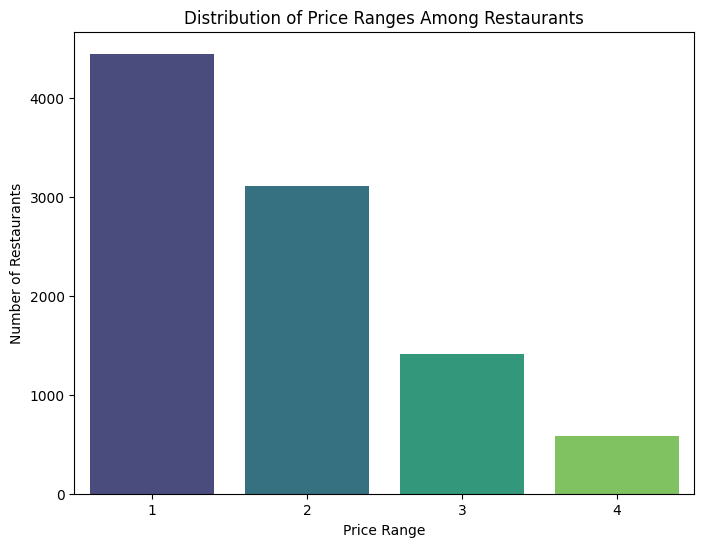

In [25]:
#Create a Bar Chart to visualize the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=price_counts.index, y=price_counts.values, palette='viridis')
plt.title('Distribution of Price Ranges Among Restaurants')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.show()

##  Insights

- Most restaurants fall under affordable or mid-range pricing categories.
- High-priced restaurants are comparatively fewer.
- Price distribution reflects customer spending patterns.
- Affordable restaurants tend to dominate the market.

## Task 4: Online Delivery 

## Objective
The objective is to analyze online delivery availability and compare restaurant ratings.

In [26]:
#The percentage of restaurants that offer online delivery
delivery_counts = df['Has Online delivery'].value_counts()

In [27]:
#Compare the average ratings
percentage_delivery = (delivery_counts / len(df)) * 100
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()

C:\Users\kspma\AppData\Local\Temp\ipykernel_20244\3605784455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_delivery.index, y=avg_rating_delivery.values, palette='coolwarm')


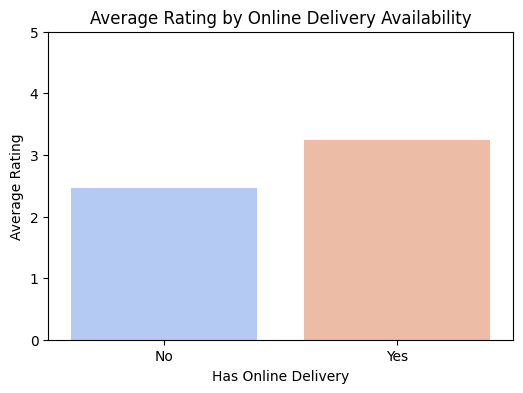

In [28]:
#Bar chart to visualize the rating difference
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_rating_delivery.index, y=avg_rating_delivery.values, palette='coolwarm')
plt.title('Average Rating by Online Delivery Availability')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Rating')
plt.ylim(0, 5) # Ratings are typically out of 5
plt.show()

##  Insights

- Online delivery services are becoming increasingly popular.
- Restaurants offering online delivery often receive competitive ratings.
- Delivery services may improve customer convenience and satisfaction.
- Restaurants without delivery services may have limited reach.